In [ ]:
# segment Window Size.  Step Size.    Overlap %.    Segments in 5 sec
#.            2 sec.      1 sec.          50%              4


import numpy as np
from scipy.io import loadmat, savemat

# Load original EEG data
data = loadmat('/Users/aryanjaswal/Projects/IMAGINE MAT/DATASET/DATASET (NEW)/cooperate.mat')
mat_key = 'eeg_data_wrt_task_rep_no_eog_256Hz_last_beep'
eeg_data = data[mat_key]
print("Original EEG shape:", eeg_data.shape)  # (8, 100)

# Settings
fs = 256  # Sampling frequency
window_size = 2 * fs  # 2 seconds = 512 samples
step_size = 1 * fs    # 1 second = 256 samples
segments_per_trial = 4  # Expected number of segments per trial

# Shape placeholders
rows, cols = eeg_data.shape
combined_data = np.empty((rows, cols * segments_per_trial), dtype=object)

# Segment with overlap
for i in range(rows):
    for j in range(cols):
        signal = eeg_data[i, j]
        if isinstance(signal, np.ndarray) and signal.shape[1] == 1280:
            for k in range(segments_per_trial):
                start = k * step_size
                end = start + window_size
                if end <= signal.shape[1]:
                    combined_data[i, j * segments_per_trial + k] = signal[:, start:end]
                else:
                    print(f"⚠️ Segment out of bounds at ({i}, {j}, {k})")
        else:
            print(f"⚠️ Unexpected shape at ({i}, {j}):", signal.shape)

# Save final .mat file
savemat('cooperate_combined_2s_win_1s_step.mat', {mat_key: combined_data})

print("✅ Final combined file with 2s window & 1s step saved. Shape:", combined_data.shape)

Original EEG shape: (6, 100)
✅ Final combined file with 3s window & 1s step saved. Shape: (6, 300)


In [19]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import welch
from scipy.integrate import simps
from scipy.stats import kurtosis, skew
import pywt

# Set sampling frequency
fs = 256

# --- Feature Functions ---

def spectral_entropy(psd):
    psd_norm = psd / np.sum(psd)
    return -np.sum(psd_norm * np.log2(psd_norm + 1e-12))

def hjorth_params(signal):
    d1 = np.diff(signal)
    d2 = np.diff(d1)
    activity = np.var(signal)
    mobility = np.std(d1) / (np.std(signal) + 1e-12)
    complexity = (np.std(d2) / (np.std(d1) + 1e-12)) / (mobility + 1e-12)
    return activity, mobility, complexity

def wavelet_entropy(signal, wavelet='db4', level=4):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    energies = np.array([np.sum(c**2) for c in coeffs])
    probs = energies / (np.sum(energies) + 1e-12)
    entropy = -np.sum(probs * np.log2(probs + 1e-12))
    return entropy, np.sum(energies)

def frequency_statistics(freqs, psd):
    psd_norm = psd / np.sum(psd)
    mean_freq = np.sum(freqs * psd_norm)
    median_freq = freqs[np.searchsorted(np.cumsum(psd_norm), 0.5)]
    peak_freq = freqs[np.argmax(psd)]
    freq_var = np.sum((freqs - mean_freq) ** 2 * psd_norm)
    return mean_freq, median_freq, freq_var, peak_freq

# --- Feature Extractor for One Trial (averaged over 64 channels) ---

def extract_mean_features(trial):  # trial shape: (64, 640)
    feature_matrix = []
    for ch in trial:
        freqs, psd = welch(ch, fs=fs)

        # Time-domain features
        mean = np.mean(ch)
        std = np.std(ch)
        sk = skew(ch)
        kurt = kurtosis(ch)
        rms = np.sqrt(np.mean(ch**2))
        ptp = np.ptp(ch)

        # Hjorth features
        act, mob, comp = hjorth_params(ch)

        # Spectral features
        spec_ent = spectral_entropy(psd)
        total_power = simps(psd, freqs)
        mean_f, med_f, var_f, peak_f = frequency_statistics(freqs, psd)

        # Wavelet features
        wave_ent, coeff_energy = wavelet_entropy(ch)

        # Combine features
        features = [
            mean, std, sk, kurt, rms, ptp,
            act, mob, comp,
            spec_ent, total_power, wave_ent, coeff_energy,
            med_f, mean_f, var_f, peak_f
        ]
        feature_matrix.append(features)

    return np.mean(np.array(feature_matrix), axis=0)  # shape: (18,)

# --- Load EEG Data and Process All Trials ---

mat_path = "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/data 2sec/cooperate_combined_2s_win_1s_step.mat"
mat_key = "eeg_data_wrt_task_rep_no_eog_256Hz_last_beep"

data = loadmat(mat_path)
eeg_data = data[mat_key]  # shape: (8, 200)

all_mean_features = []

for i in range(eeg_data.shape[0]):
    for j in range(eeg_data.shape[1]):
        trial = eeg_data[i, j]  # shape: (64, 640)
        trial_feats = extract_mean_features(trial)
        all_mean_features.append(trial_feats)

X = np.array(all_mean_features)  # shape: (1600, 18)
print("✅ Final mean feature matrix shape:", X.shape)

# --- Save to CSV with Feature Labels ---

feature_names = [
    'mean', 'std', 'skewness', 'kurtosis', 'rms', 'peak_to_peak',
    'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity',
    'spectral_entropy', 'total_power', 'wavelet_entropy', 'coeff_energy',
    'median_frequency', 'mean_frequency', 'frequency_variance', 'peak_frequency'
]

csv_path = "cooperate_2sec_features.csv"
df = pd.DataFrame(X, columns=feature_names)
df.to_csv(csv_path, index=False)

print(f"✅ Mean features saved to: {csv_path}")

/var/folders/jg/v0bbfb4d6z31kv3sqwt32tr40000gn/T/ipykernel_10852/543335060.py:61: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  total_power = simps(psd, freqs)


✅ Final mean feature matrix shape: (2400, 17)
✅ Mean features saved to: cooperate_2sec_features.csv


In [27]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/independent_2sec_features.csv", header=None)

# Add '0' as the last column
df['label'] = 8

# Save the updated CSV
df.to_csv("/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/independent_2sec_features.csv", index=False, header=False)

In [28]:
import pandas as pd

# List your CSV files here
file_list = ["/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/a_2sec_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/i_2sec_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/u_2sec_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/out_2sec_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/in_2sec_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/up_2sec_features.csv",
    "//Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/cooperate_2sec_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/independent_2sec_features.csv"
            ]  # Replace with actual file names

all_labels = []

for file in file_list:
    df = pd.read_csv(file, header=None, skiprows=1)  # Skip header row
    last_col = df.iloc[:, -1]
    all_labels.extend(last_col.tolist())

# Convert to DataFrame and add "label" as first cell
label_df = pd.DataFrame(all_labels, columns=["label"])

# Save to CSV with header
label_df.to_csv("1sec_labels.csv", index=False)

In [29]:
import pandas as pd

# List your CSV files directly
csv_files = [
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/a_2sec_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/i_2sec_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/u_2sec_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/out_2sec_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/in_2sec_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/up_2sec_features.csv",
    "//Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/cooperate_2sec_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/independent_2sec_features.csv"
]

# List to store processed DataFrames
df_list = []

# Loop through each file
for file in csv_files:
    df = pd.read_csv(file)
    if df.columns[-1] == "5":
        df.drop("5", axis=1, inplace=True)  # Remove the column explicitly by label
    else:
        df.drop(df.columns[-1], axis=1, inplace=True)  # Fallback: drop last column
    df_list.append(df)

# Combine all dataframes vertically
combined_df = pd.concat(df_list, ignore_index=True)

# Save to a new CSV file
combined_df.to_csv('combined.csv', index=False)

print("Combined CSV saved as 'combined.csv' without the last column '5'")

Combined CSV saved as 'combined.csv' without the last column '5'



===== Random Forest =====
Fold 1: Accuracy = 0.2931
Fold 2: Accuracy = 0.2981
Fold 3: Accuracy = 0.3065
Fold 4: Accuracy = 0.2875
Fold 5: Accuracy = 0.2829
Fold 6: Accuracy = 0.2926
Fold 7: Accuracy = 0.2829
Fold 8: Accuracy = 0.2815
Fold 9: Accuracy = 0.2958
Fold 10: Accuracy = 0.3097
Average Accuracy = 0.2931

===== Decision Tree =====
Fold 1: Accuracy = 0.2329
Fold 2: Accuracy = 0.2255
Fold 3: Accuracy = 0.2468
Fold 4: Accuracy = 0.2343
Fold 5: Accuracy = 0.2338
Fold 6: Accuracy = 0.2231
Fold 7: Accuracy = 0.2329
Fold 8: Accuracy = 0.2269
Fold 9: Accuracy = 0.2417
Fold 10: Accuracy = 0.2361
Average Accuracy = 0.2334

===== Gradient Boosting =====
Fold 1: Accuracy = 0.2880
Fold 2: Accuracy = 0.2481
Fold 3: Accuracy = 0.2648
Fold 4: Accuracy = 0.2579
Fold 5: Accuracy = 0.2551
Fold 6: Accuracy = 0.2699
Fold 7: Accuracy = 0.2639
Fold 8: Accuracy = 0.2667
Fold 9: Accuracy = 0.2690
Fold 10: Accuracy = 0.2685
Average Accuracy = 0.2652


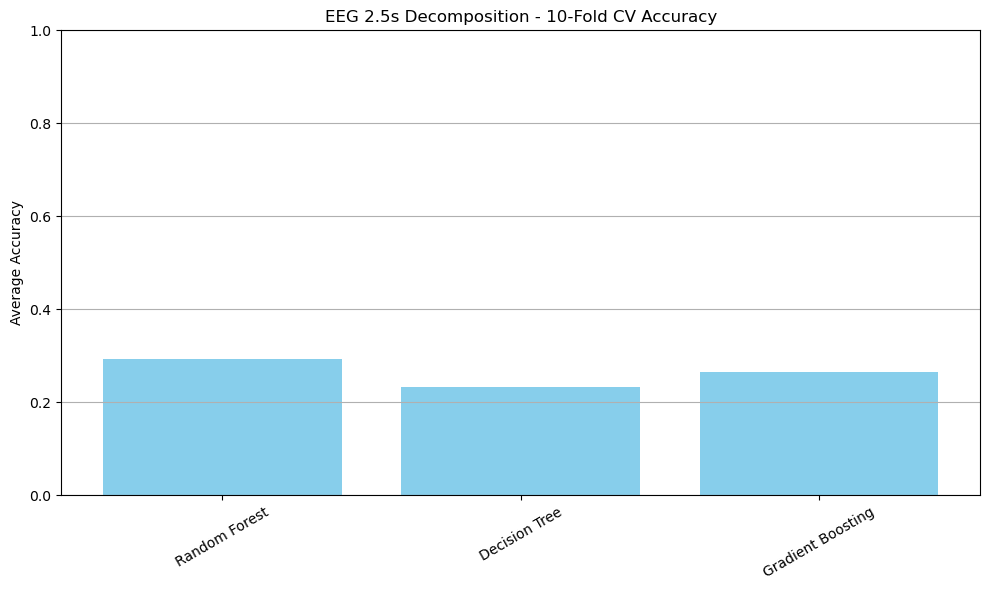

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Load data
X = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/combined.csv', header=None, skiprows=1)
y = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/2 sec/feature 2sec/labels.csv', header=None, skiprows=1).squeeze()

# Feature scaling - improves SVM, KNN, etc.
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 10-fold stratified cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define models (with better tuned hyperparameters)
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=5, random_state=42),
    
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=4, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    # Optional: Add SVM or Logistic Regression with tuning
    
}

# Evaluate models
model_accuracies = {}

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")
    fold = 1
    accuracies = []

    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        print(f"Fold {fold}: Accuracy = {acc:.4f}")
        fold += 1

    avg_acc = sum(accuracies) / len(accuracies)
    model_accuracies[model_name] = avg_acc
    print(f"Average Accuracy = {avg_acc:.4f}")

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(model_accuracies.keys(), model_accuracies.values(), color='skyblue')
plt.ylabel('Average Accuracy')
plt.ylim(0, 1)
plt.title('EEG 2.5s Decomposition - 10-Fold CV Accuracy')
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

/var/folders/jg/v0bbfb4d6z31kv3sqwt32tr40000gn/T/ipykernel_1050/135059086.py:61: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  total_power = simps(psd, freqs)


✅ Final mean feature matrix shape: (1800, 17)
✅ Mean features saved to: cooperate_3sec_features.csv
